# STOR 120 - Homework 3: Histograms & Functions

Please complete this notebook by filling in the cells provided. 

In [1]:
# Don't change this cell; just run it. 
import numpy as np
from datascience import *

# These lines do some fancy plotting magic.
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

## 1. Histograms


Consider the following scatter plot: 

<img src="https://raw.githubusercontent.com/JA-McLean/STOR120/3418736ae701a8aa3e88e5b4ac9cdb6885732333/Images/hw03-scatter.png">

The axes of the plot represent values of two variables: $x$ and $y$. 

Suppose we have a table called `t` that has two columns in it:

- `x`: a column containing the x-values of the points in the scatter plot
- `y`: a column containing the y-values of the points in the scatter plot

Below, you are given two histograms, each of which corresponds to either column `x` or column `y`. 

**Histogram A:** 
<br>
<img src="https://raw.githubusercontent.com/JA-McLean/STOR120/6a3c6349cf16cd6fb68e00ce62aa7e6654dc018f/Images/hw03-var1.png">

**Histogram B:**
<br>
<img src="https://raw.githubusercontent.com/JA-McLean/STOR120/6a3c6349cf16cd6fb68e00ce62aa7e6654dc018f/Images/hw03-var2.png">

**Question 1.1.** Suppose we run `t.hist('y')`. Which histogram does this code produce? Assign `histogram_column_y` to either 1 or 2.

1. Histogram A
2. Histogram B

In [2]:
histogram_column_y = 1

**Question 1.2.** State at least one reason why you chose the histogram from Question 1.1. Make sure to indicate which histogram you selected (ex: "I chose histogram A because ...").

I chose Histogram A. In the scatter plot, the y-values fall into two distinct clusters — one centered around $y = -1$ and one centered around $y = 1$ — with a clear gap between about $y = -0.5$ and $y = 0.5$. Histogram A is the only histogram that is bimodal with a gap over exactly that range, while Histogram B is unimodal with no gaps, so Histogram A must be the histogram of the y-values.

**Question 1.3.** Suppose we run `t.hist('x')`. Which histogram does this code produce? `Assign histogram_column_x` to either 1 or 2.

1. Histogram A
2. Histogram B

In [3]:
histogram_column_x = 2

**Question 1.4.** State at least one reason why you chose the histogram from Question 1.3.  Make sure to indicate which histogram you selected (ex: "I chose histogram A because ...").

I chose Histogram B. In the scatter plot, the x-values form a single continuous cluster with no gaps: they span roughly $-2.2$ to $2.7$, are centered between $-1$ and $0$, and taper off on both sides (most points lie between $-1$ and $1$). This matches the unimodal, roughly bell-shaped Histogram B. Histogram A has a large gap in the middle of its range, and no such gap exists among the x-values.

## 2. Uber


Below we load tables each containing over 100,000 weekday Uber rides in the Atlanta and Los Angeles metropolitan areas from the [Uber Movement](https://movement.uber.com) project. The `sourceid` and `dstid` columns contain codes corresponding to start and end locations of each ride. The `hod` column contains codes corresponding to the hour of the day the ride took place. The `ride time` column contains the length of the ride, in minutes.

In [4]:
atlanta = Table.read_table("../../shared/Data/atlanta.csv")
los_angeles = Table.read_table("../../shared/Data/los_angeles.csv")
print("Atlanta Table")
atlanta.show(4)
print("Los Angeles Table")
los_angeles.show(4)

Atlanta Table


sourceid,dstid,hod,ride time
754,10,16,13.7982
776,418,22,12.5705
772,458,22,24.5393
764,538,22,23.1782


Los Angeles Table


sourceid,dstid,hod,ride time
506,478,2,5.78333
458,59,19,3.23133
454,99,19,22.4833
519,348,2,6.5735


**Question 2.1.** Produce a histogram of all ride times in Atlanta using the given bins. 

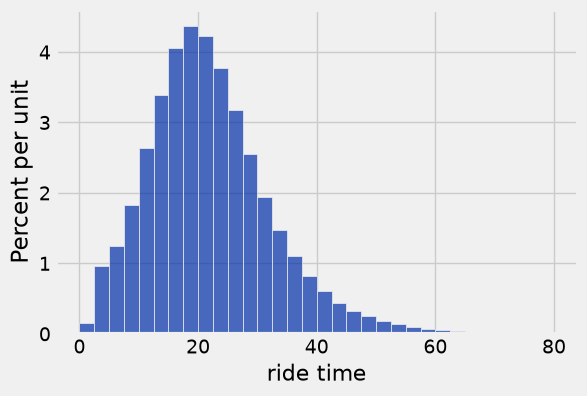

In [5]:
equal_bins = np.arange(0, 81, 2.5)
atlanta.hist('ride time', bins=equal_bins)

# Don't delete the following line!
plots.ylim(0, 0.046);

**Question 2.2.** Produce a histogram of all ride times in Los Angeles using the given bins.

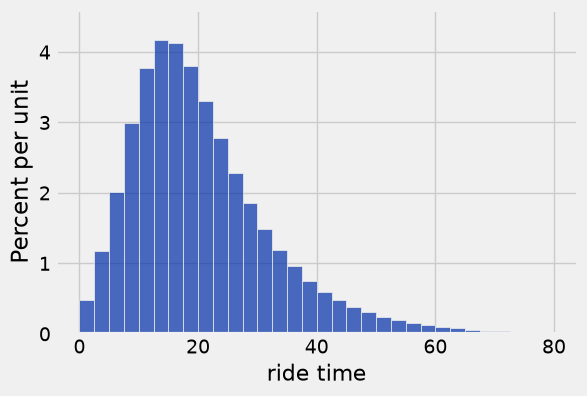

In [6]:
los_angeles.hist('ride time', bins=equal_bins)

# Don't delete the following line!
plots.ylim(0, 0.046);

**Question 2.3.** Assign `atlanta_10to15` and `los_angeles_10to15` to the percentage of rides that are 10-15 minutes long (including 10 but not including 15) in the respective metropolitan areas. Use the height variables provided below in order to compute the percentages. Your solution should only use height variables (heights of the bars of the histograms), numbers, and mathematical operations. You should not access the tables atlanta and los_angeles in any way.

In [7]:
atlanta_10to12_half_height = 0.02642
los_angeles_10to12_half_height = 0.03772
atlanta_12_half_to_15_height = 0.03393
los_angeles_12_half_to_15_height = 0.04160

atlanta_10to15 = (atlanta_10to12_half_height + atlanta_12_half_to_15_height) * 2.5
los_angeles_10to15 = (los_angeles_10to12_half_height + los_angeles_12_half_to_15_height) * 2.5

round(atlanta_10to15, 2), round(los_angeles_10to15, 2)

(0.15, 0.2)

**Question 2.4.** What are difference betweens the two histograms. What might be causing this?

**Hint:** Try thinking about external factors that may be causing the difference!

The two histograms show that Los Angeles ride times are generally longer and more spread out than Atlanta's: the Los Angeles distribution is flatter and shifted to the right, with a larger share of rides taking 10–15 minutes (about 20% versus about 15% in Atlanta), while Atlanta's ride times are more concentrated at shorter durations. This could be caused by external factors such as Los Angeles' notoriously heavy traffic congestion and its much larger, more spread-out metropolitan area — longer travel distances and slower speeds mean longer ride times — whereas trips in Atlanta tend to cover shorter distances and/or move faster.

## 3. Bicycle Crashes in Chapel Hill

Dr. McLean lives not far from campus and is considering commuting from home to Hanes Hall on his bicycle. First he decides that he needs to investigate if it's safe to ride in Chapel Hill. Chapel Hill Open data provides a data set of all bicycle crashes reported in North Carolina (12,173 of them!) that occurred between 2007 and 2019. Begin by importing the dataset in the cell below.

In [8]:
Bike = Table.read_table('../../shared/Data/NCDOT_BikePedCrash.csv')
Bike.show(5)

X,Y,OBJECTID_1,AmbulanceR,BikeAge,BikeAgeGrp,BikeAlcDrg,BikeAlcFlg,BikeDir,BikeInjury,BikePos,BikeRace,BikeSex,City,County,CrashAlcoh,CrashDay,CrashGrp,CrashHour,CrashID,CrashLoc,CrashMonth,CrashSevr,CrashType,CrashYear,Developmen,DrvrAge,DrvrAgeGrp,DrvrAlcDrg,DrvrAlcFlg,DrvrInjury,DrvrRace,DrvrSex,DrvrVehTyp,HitRun,Latitude,LightCond,Locality,Longitude,NumBicsAin,NumBicsBin,NumBicsCin,NumBicsKil,NumBicsNoi,NumBicsTot,NumBicsUin,NumLanes,NumUnits,RdCharacte,RdClass,RdConditio,RdConfig,RdDefects,RdFeature,RdSurface,Region,RuralUrban,SpeedLimit,TraffCntrl,Weather,Workzone,OBJECTID
-78.8839,36.0395,1,Yes,11,11-15,.,No,With Traffic,B: Suspected Minor Injury,Sidewalk / Crosswalk / Driveway Crossing,Black,Male,Durham,Durham,No,Tuesday,Parallel Paths - Other Circumstances,16,101878313,Non-Intersection,January,B: Suspected Minor Injury,Bicyclist Ride Out - Parallel Path,2007,Residential,35,30-39,.,No,O: No Injury,White,Male,Passenger Car,No,36.0395,Daylight,Urban (>70% Developed),-78.8839,.,.,.,.,.,.,.,1 lane,2,Straight - Level,Local Street,Dry,"Two-Way, Divided, Unprotected Median",nan,No Special Feature,Smooth Asphalt,Piedmont,Urban,30 - 35 MPH,No Control Present,Clear,No,1
-78.7828,35.7511,2,Yes,20,20-24,.,No,Facing Traffic,C: Possible Injury,Sidewalk / Crosswalk / Driveway Crossing,Hispanic,Male,Cary,Wake,No,Friday,Motorist Failed to Yield - Signalized Intersection,9,101885911,Intersection,January,C: Possible Injury,Motorist Drive Out - Right Turn on Red,2007,Residential,64,60-69,.,No,O: No Injury,White,Male,Passenger Car,No,35.7511,Daylight,Urban (>70% Developed),-78.7828,.,.,.,.,.,.,.,3 lanes,2,Straight - Grade,Local Street,Dry,"Two-Way, Divided, Unprotected Median",nan,Four-Way Intersection,Smooth Asphalt,Piedmont,Urban,30 - 35 MPH,Stop And Go Signal,Clear,No,2
-80.6978,35.0847,3,Yes,37,30-39,.,No,Unknown,B: Suspected Minor Injury,Non-Roadway,Black,Male,Stallings,Union,No,Monday,Non-Roadway,17,101886055,Non-Roadway,January,B: Suspected Minor Injury,Non-Roadway,2007,Commercial,39,30-39,.,No,O: No Injury,White,Female,Passenger Car,No,35.0847,Dusk,Urban (>70% Developed),-80.6978,.,.,.,.,.,.,.,2 lanes,2,Straight - Level,Public Vehicular Area,Dry,"Two-Way, Not Divided",nan,No Special Feature,Smooth Asphalt,Piedmont,Urban,20 - 25 MPH,No Control Present,Cloudy,No,3
-80.4793,35.6844,4,Yes,30,30-39,.,No,With Traffic,C: Possible Injury,Travel Lane,White,Male,Salisbury,Rowan,No,Friday,Motorist Left Turn / Merge,17,101890155,Intersection,January,C: Possible Injury,Motorist Left Turn - Opposite Direction,2007,Commercial,999,Unknown,.,No,Unknown Injury,Unknown/Missing,Unknown,Sport Utility,Yes,35.6844,Daylight,Urban (>70% Developed),-80.4793,.,.,.,.,.,.,.,2 lanes,2,Straight - Grade,Local Street,Dry,"Two-Way, Not Divided",nan,Four-Way Intersection,Smooth Asphalt,Piedmont,Urban,30 - 35 MPH,No Control Present,Cloudy,No,4
-78.9045,34.9994,5,Yes,45,40-49,.,No,With Traffic,B: Suspected Minor Injury,Travel Lane,Black,Male,Fayetteville,Cumberland,No,Friday,Motorist Overtaking Bicyclist,12,101899756,Non-Intersection,January,B: Suspected Minor Injury,Motorist Overtaking - Bicyclist Swerved,2007,Commercial,51,50-59,.,No,O: No Injury,Black,Female,Van,No,34.9994,Daylight,Urban (>70% Developed),-78.9044,.,.,.,.,.,.,.,2 lanes,2,Straight - Level,Local Street,Dry,"Two-Way, Not Divided",nan,No Special Feature,Coarse Asphalt,Coastal,Urban,30 - 35 MPH,"Double Yellow Line, No Passing Zone",Clear,No,5


**Question 3.1** Construct a new table `Bike_CH` that contains only the crashes that occurred in `Chapel Hill`. 

In [9]:
Bike_CH = Bike.where('City', 'Chapel Hill')
Bike_CH

X,Y,OBJECTID_1,AmbulanceR,BikeAge,BikeAgeGrp,BikeAlcDrg,BikeAlcFlg,BikeDir,BikeInjury,BikePos,BikeRace,BikeSex,City,County,CrashAlcoh,CrashDay,CrashGrp,CrashHour,CrashID,CrashLoc,CrashMonth,CrashSevr,CrashType,CrashYear,Developmen,DrvrAge,DrvrAgeGrp,DrvrAlcDrg,DrvrAlcFlg,DrvrInjury,DrvrRace,DrvrSex,DrvrVehTyp,HitRun,Latitude,LightCond,Locality,Longitude,NumBicsAin,NumBicsBin,NumBicsCin,NumBicsKil,NumBicsNoi,NumBicsTot,NumBicsUin,NumLanes,NumUnits,RdCharacte,RdClass,RdConditio,RdConfig,RdDefects,RdFeature,RdSurface,Region,RuralUrban,SpeedLimit,TraffCntrl,Weather,Workzone,OBJECTID
-79.059,35.9183,284,Yes,12,11-15,.,No,Unknown,B: Suspected Minor Injury,Travel Lane,Black,Male,Chapel Hill,Orange,No,Saturday,Bicyclist Failed to Yield - Sign-Controlled Intersection,16,102031450,Intersection,May,B: Suspected Minor Injury,Bicyclist Ride Through - Sign-Controlled Intersection,2007,Residential,22,20-24,.,No,O: No Injury,White,Male,Passenger Car,No,35.9183,Daylight,Urban (>70% Developed),-79.059,.,.,.,.,.,.,.,2 lanes,2,Straight - Grade,Local Street,Dry,"Two-Way, Not Divided",nan,T-Intersection,Smooth Asphalt,Piedmont,Urban,20 - 25 MPH,Stop Sign,Cloudy,No,284
-79.048,35.916,372,No,22,20-24,.,Yes,With Traffic,C: Possible Injury,Travel Lane,Unknown/Missing,Male,Chapel Hill,Orange,Yes,Thursday,Motorist Failed to Yield - Sign-Controlled Intersection,23,102054187,Intersection,May,C: Possible Injury,Motorist Drive Out - Sign-Controlled Intersection,2007,Residential,48,40-49,.,No,O: No Injury,Black,Male,Sport Utility,No,35.916,Dark - Roadway Not Lighted,Urban (>70% Developed),-79.048,.,.,.,.,.,.,.,4 lanes,2,Straight - Level,Local Street,Dry,"Two-Way, Not Divided",nan,No Special Feature,Smooth Asphalt,Piedmont,Urban,20 - 25 MPH,Stop Sign,Clear,No,372
-79.0551,35.9052,519,Yes,34,30-39,.,No,Facing Traffic,C: Possible Injury,Travel Lane,Asian,Male,Chapel Hill,Orange,No,Tuesday,Loss of Control / Turning Error,17,102085660,Intersection,July,C: Possible Injury,Bicyclist Turning Error - Left Turn,2007,Residential,39,30-39,.,No,O: No Injury,White,Male,Passenger Car,No,35.9052,Daylight,Urban (>70% Developed),-79.0551,.,.,.,.,.,.,.,2 lanes,2,Straight - Level,Local Street,Wet,"Two-Way, Not Divided",nan,T-Intersection,Smooth Asphalt,Piedmont,Urban,20 - 25 MPH,Stop Sign,Rain,No,519
-79.0562,35.9099,763,No,53,50-59,.,No,With Traffic,C: Possible Injury,Unknown,White,Male,Chapel Hill,Orange,No,Wednesday,Motorist Left Turn / Merge,8,102136520,Non-Intersection,September,C: Possible Injury,Motorist Left Turn - Opposite Direction,2007,Residential,34,30-39,.,No,O: No Injury,White,Male,Passenger Car,No,35.9099,Daylight,Urban (>70% Developed),-79.0562,.,.,.,.,.,.,.,2 lanes,2,Straight - Level,Local Street,Dry,"Two-Way, Not Divided",nan,No Special Feature,Smooth Asphalt,Piedmont,Urban,20 - 25 MPH,No Control Present,Clear,No,763
-79.0342,35.9292,824,Yes,18,16-19,.,No,With Traffic,B: Suspected Minor Injury,Unknown,White,Male,Chapel Hill,Orange,No,Saturday,Bicyclist Failed to Yield - Signalized Intersection,14,102152366,Intersection,September,B: Suspected Minor Injury,Bicyclist Ride Out - Signalized Intersection,2007,Commercial,68,60-69,.,No,O: No Injury,White,Female,Passenger Car,No,35.9293,Daylight,Urban (>70% Developed),-79.0342,.,.,.,.,.,.,.,9 or more lanes,2,Straight - Level,Local Street,Dry,"Two-Way, Not Divided",nan,Four-Way Intersection,Smooth Asphalt,Piedmont,Urban,30 - 35 MPH,Stop And Go Signal,Clear,No,824
-79.048,35.905,980,Yes,21,20-24,.,No,Unknown,B: Suspected Minor Injury,Multi-use Path,White,Male,Chapel Hill,Orange,No,Tuesday,Non-Roadway,18,102208751,Non-Roadway,December,B: Suspected Minor Injury,Non-Roadway,2007,Institutional,38,30-39,.,No,O: No Injury,Asian,Male,Passenger Car,No,35.9051,Dark - Lighted Roadway,Urban (>70% Developed),-79.048,.,.,.,.,.,.,.,1 lane,2,Straight - Grade,Public Vehicular Area,Dry,"One-Way, Not Divided",nan,No Special Feature,Coarse Asphalt,Piedmont,Urban,5 - 15 MPH,No Control Present,Clear,No,980
-79.0644,35.8916,1085,No,43,40-49,.,

**Question 3.2** Use the `Bike_CH` table to determine the average number of reported bicycle crashes per year in Chapel Hill and assign this value to `ave_per_year`.

In [10]:
num_years = 2019 - 2007 + 1
ave_per_year = Bike_CH.num_rows / num_years
ave_per_year

11.923076923076923

Of the reported bicycle crashes that occurred in Chapel Hill, which of them occurred within 1.5 miles of Dr. McLean's office in Hanes Hall? Answering this question will take a few steps. Since the longitude (`X`) and latitude (`Y`) of each bicycle crash is listed in the table, we can use those to determine a distance from Hanes Hall. Googlemaps reports that the longitude and lattide of Hanes Hall is (-79.0513, 35.9107). To convert the differences in these latitudes and longitudes from Hanes Hall, we'll need to use Haversine's Formula.

### 3.1 Haversine Formula

It might seem straightforward to pull out a map and measure the distance between two distant points, however, the larger the distance the bigger the distortion caused by traveling on the curved surface of the Earth as opposed to flat 2D space. So while the distance you measure to your neighbouring town won't be too bad, if you're measuring between London and Rio the curvature of the Earth will make a big difference to the distance that you'll travel. To help figure out the correct distance there's the haversine formula.

The haversine formula allows you to calculate the shortest distance between two points on a sphere using their latitudes and longitudes — this will be the arc between them on the great circle that includes both points. A great circle is a circle on a sphere with the same center as the sphere, like the Equator. The haversine formula isn't perfect in practice, as Earth isn't a perfect sphere

https://sketchplanations.com/the-haversine-formula

<img src="https://raw.githubusercontent.com/JA-McLean/STOR120/6a3c6349cf16cd6fb68e00ce62aa7e6654dc018f/Images/haversine.png">

The formula itself is a bit complicated, so it's written for you in the cell below. The arguments are the latitude and longitudes of two points on earth, with the function returning the distance between them in kilometers. Run the cell below.

In [11]:
from math import radians, cos, sin, asin, sqrt
def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    """
    # convert decimal degrees to radians 
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    # haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    km = 6367 * c
    return km

**Question 3.1.1.** Use the haversine formula to determine the distance in kilometers for the first bicycle crash in the `Bike_CH` table and Hanes Hall. Assign this value to `First_Crash_Distance`. 

Do we really need to consider the curvature of the Earth when traveling locally in Chapel Hill? **Absolutely not** ... but we're going to do it anyways!

In [12]:
First_Crash_Distance = haversine(Bike_CH.column('X').item(0), Bike_CH.column('Y').item(0), -79.0513, 35.9107)
First_Crash_Distance

1.0871866784104223

**Question 3.1.2.** Next you will determine the distance of each bicycle crash in the `Bike_CH` table from Hanes Hall. Begin by creating a table `Bike_CH_with_Hanes` that contains the same rows and columns as `Bike_CH`, and adds two new columns: `X Hanes` and `Y Hanes`. These columns will have the values for the longitude of Hanes Hall (`X Hanes`) and latitude of Hanes Hall (`Y Hanes`) repeated for each row of the column. To do this, you can use the *np.repeat*() function from numpy. This function takes in two arguments, first the value that you want to repeat, and then how many times you want to repeat it. For instance in the cell below an array is created by repeating 0 20 times.

In [13]:
np.repeat(0, 20)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [14]:
Bike_CH_with_Hanes = Bike_CH.with_columns(
    'X Hanes', np.repeat(-79.0513, Bike_CH.num_rows),
    'Y Hanes', np.repeat(35.9107, Bike_CH.num_rows))
Bike_CH_with_Hanes

X,Y,OBJECTID_1,AmbulanceR,BikeAge,BikeAgeGrp,BikeAlcDrg,BikeAlcFlg,BikeDir,BikeInjury,BikePos,BikeRace,BikeSex,City,County,CrashAlcoh,CrashDay,CrashGrp,CrashHour,CrashID,CrashLoc,CrashMonth,CrashSevr,CrashType,CrashYear,Developmen,DrvrAge,DrvrAgeGrp,DrvrAlcDrg,DrvrAlcFlg,DrvrInjury,DrvrRace,DrvrSex,DrvrVehTyp,HitRun,Latitude,LightCond,Locality,Longitude,NumBicsAin,NumBicsBin,NumBicsCin,NumBicsKil,NumBicsNoi,NumBicsTot,NumBicsUin,NumLanes,NumUnits,RdCharacte,RdClass,RdConditio,RdConfig,RdDefects,RdFeature,RdSurface,Region,RuralUrban,SpeedLimit,TraffCntrl,Weather,Workzone,OBJECTID,X Hanes,Y Hanes
-79.059,35.9183,284,Yes,12,11-15,.,No,Unknown,B: Suspected Minor Injury,Travel Lane,Black,Male,Chapel Hill,Orange,No,Saturday,Bicyclist Failed to Yield - Sign-Controlled Intersection,16,102031450,Intersection,May,B: Suspected Minor Injury,Bicyclist Ride Through - Sign-Controlled Intersection,2007,Residential,22,20-24,.,No,O: No Injury,White,Male,Passenger Car,No,35.9183,Daylight,Urban (>70% Developed),-79.059,.,.,.,.,.,.,.,2 lanes,2,Straight - Grade,Local Street,Dry,"Two-Way, Not Divided",nan,T-Intersection,Smooth Asphalt,Piedmont,Urban,20 - 25 MPH,Stop Sign,Cloudy,No,284,-79.0513,35.9107
-79.048,35.916,372,No,22,20-24,.,Yes,With Traffic,C: Possible Injury,Travel Lane,Unknown/Missing,Male,Chapel Hill,Orange,Yes,Thursday,Motorist Failed to Yield - Sign-Controlled Intersection,23,102054187,Intersection,May,C: Possible Injury,Motorist Drive Out - Sign-Controlled Intersection,2007,Residential,48,40-49,.,No,O: No Injury,Black,Male,Sport Utility,No,35.916,Dark - Roadway Not Lighted,Urban (>70% Developed),-79.048,.,.,.,.,.,.,.,4 lanes,2,Straight - Level,Local Street,Dry,"Two-Way, Not Divided",nan,No Special Feature,Smooth Asphalt,Piedmont,Urban,20 - 25 MPH,Stop Sign,Clear,No,372,-79.0513,35.9107
-79.0551,35.9052,519,Yes,34,30-39,.,No,Facing Traffic,C: Possible Injury,Travel Lane,Asian,Male,Chapel Hill,Orange,No,Tuesday,Loss of Control / Turning Error,17,102085660,Intersection,July,C: Possible Injury,Bicyclist Turning Error - Left Turn,2007,Residential,39,30-39,.,No,O: No Injury,White,Male,Passenger Car,No,35.9052,Daylight,Urban (>70% Developed),-79.0551,.,.,.,.,.,.,.,2 lanes,2,Straight - Level,Local Street,Wet,"Two-Way, Not Divided",nan,T-Intersection,Smooth Asphalt,Piedmont,Urban,20 - 25 MPH,Stop Sign,Rain,No,519,-79.0513,35.9107
-79.0562,35.9099,763,No,53,50-59,.,No,With Traffic,C: Possible Injury,Unknown,White,Male,Chapel Hill,Orange,No,Wednesday,Motorist Left Turn / Merge,8,102136520,Non-Intersection,September,C: Possible Injury,Motorist Left Turn - Opposite Direction,2007,Residential,34,30-39,.,No,O: No Injury,White,Male,Passenger Car,No,35.9099,Daylight,Urban (>70% Developed),-79.0562,.,.,.,.,.,.,.,2 lanes,2,Straight - Level,Local Street,Dry,"Two-Way, Not Divided",nan,No Special Feature,Smooth Asphalt,Piedmont,Urban,20 - 25 MPH,No Control Present,Clear,No,763,-79.0513,35.9107
-79.0342,35.9292,824,Yes,18,16-19,.,No,With Traffic,B: Suspected Minor Injury,Unknown,White,Male,Chapel Hill,Orange,No,Saturday,Bicyclist Failed to Yield - Signalized Intersection,14,102152366,Intersection,September,B: Suspected Minor Injury,Bicyclist Ride Out - Signalized Intersection,2007,Commercial,68,60-69,.,No,O: No Injury,White,Female,Passenger Car,No,35.9293,Daylight,Urban (>70% Developed),-79.0342,.,.,.,.,.,.,.,9 or more lanes,2,Straight - Level,Local Street,Dry,"Two-Way, Not Divided",nan,Four-Way Intersection,Smooth Asphalt,Piedmont,Urban,30 - 35 MPH,Stop And Go Signal,Clear,No,824,-79.0513,35.9107
-79.048,35.905,980,Yes,21,20-24,.,No,Unknown,B: Suspected Minor Injury,Multi-use Path,White,Male,Chapel Hill,Orange,No,Tuesday,Non-Roadway,18,102208751,Non-Roadway,December,B: Suspected Minor Injury,Non-Roadway,2007,Institutional,38,30-39,.,No,O: No Injury,Asian,Male,Passenger Car,No,35.9051,Dark - Lighted Roadway,Urban (>70% Developed),-79.048,.,.,.,.,.,.,.,1 lane,2,Straight - Grade,Public Vehicular Area,Dry,"One-Way, Not Divided",nan,No Special Feature,Coarse A

**Question 3.1.3.** Next you will use the `apply` function to determine the distances of each bicycle crash from Hanes Hall. Create a new table `Bike_CH_Dist_From_Hanes` which contains the same columns and rows as `Bike_CH_with_Hanes` as well as a new column `Distance From Hanes` which contains the values in kilometers for the distance from each bicycle accident from Hanes Hall. 

In [15]:
Bike_CH_Dist_From_Hanes = Bike_CH_with_Hanes.with_column(
    'Distance From Hanes',
    Bike_CH_with_Hanes.apply(haversine, 'X', 'Y', 'X Hanes', 'Y Hanes'))
Bike_CH_Dist_From_Hanes

X,Y,OBJECTID_1,AmbulanceR,BikeAge,BikeAgeGrp,BikeAlcDrg,BikeAlcFlg,BikeDir,BikeInjury,BikePos,BikeRace,BikeSex,City,County,CrashAlcoh,CrashDay,CrashGrp,CrashHour,CrashID,CrashLoc,CrashMonth,CrashSevr,CrashType,CrashYear,Developmen,DrvrAge,DrvrAgeGrp,DrvrAlcDrg,DrvrAlcFlg,DrvrInjury,DrvrRace,DrvrSex,DrvrVehTyp,HitRun,Latitude,LightCond,Locality,Longitude,NumBicsAin,NumBicsBin,NumBicsCin,NumBicsKil,NumBicsNoi,NumBicsTot,NumBicsUin,NumLanes,NumUnits,RdCharacte,RdClass,RdConditio,RdConfig,RdDefects,RdFeature,RdSurface,Region,RuralUrban,SpeedLimit,TraffCntrl,Weather,Workzone,OBJECTID,X Hanes,Y Hanes,Distance From Hanes
-79.059,35.9183,284,Yes,12,11-15,.,No,Unknown,B: Suspected Minor Injury,Travel Lane,Black,Male,Chapel Hill,Orange,No,Saturday,Bicyclist Failed to Yield - Sign-Controlled Intersection,16,102031450,Intersection,May,B: Suspected Minor Injury,Bicyclist Ride Through - Sign-Controlled Intersection,2007,Residential,22,20-24,.,No,O: No Injury,White,Male,Passenger Car,No,35.9183,Daylight,Urban (>70% Developed),-79.059,.,.,.,.,.,.,.,2 lanes,2,Straight - Grade,Local Street,Dry,"Two-Way, Not Divided",nan,T-Intersection,Smooth Asphalt,Piedmont,Urban,20 - 25 MPH,Stop Sign,Cloudy,No,284,-79.0513,35.9107,1.08719
-79.048,35.916,372,No,22,20-24,.,Yes,With Traffic,C: Possible Injury,Travel Lane,Unknown/Missing,Male,Chapel Hill,Orange,Yes,Thursday,Motorist Failed to Yield - Sign-Controlled Intersection,23,102054187,Intersection,May,C: Possible Injury,Motorist Drive Out - Sign-Controlled Intersection,2007,Residential,48,40-49,.,No,O: No Injury,Black,Male,Sport Utility,No,35.916,Dark - Roadway Not Lighted,Urban (>70% Developed),-79.048,.,.,.,.,.,.,.,4 lanes,2,Straight - Level,Local Street,Dry,"Two-Way, Not Divided",nan,No Special Feature,Smooth Asphalt,Piedmont,Urban,20 - 25 MPH,Stop Sign,Clear,No,372,-79.0513,35.9107,0.664417
-79.0551,35.9052,519,Yes,34,30-39,.,No,Facing Traffic,C: Possible Injury,Travel Lane,Asian,Male,Chapel Hill,Orange,No,Tuesday,Loss of Control / Turning Error,17,102085660,Intersection,July,C: Possible Injury,Bicyclist Turning Error - Left Turn,2007,Residential,39,30-39,.,No,O: No Injury,White,Male,Passenger Car,No,35.9052,Daylight,Urban (>70% Developed),-79.0551,.,.,.,.,.,.,.,2 lanes,2,Straight - Level,Local Street,Wet,"Two-Way, Not Divided",nan,T-Intersection,Smooth Asphalt,Piedmont,Urban,20 - 25 MPH,Stop Sign,Rain,No,519,-79.0513,35.9107,0.701111
-79.0562,35.9099,763,No,53,50-59,.,No,With Traffic,C: Possible Injury,Unknown,White,Male,Chapel Hill,Orange,No,Wednesday,Motorist Left Turn / Merge,8,102136520,Non-Intersection,September,C: Possible Injury,Motorist Left Turn - Opposite Direction,2007,Residential,34,30-39,.,No,O: No Injury,White,Male,Passenger Car,No,35.9099,Daylight,Urban (>70% Developed),-79.0562,.,.,.,.,.,.,.,2 lanes,2,Straight - Level,Local Street,Dry,"Two-Way, Not Divided",nan,No Special Feature,Smooth Asphalt,Piedmont,Urban,20 - 25 MPH,No Control Present,Clear,No,763,-79.0513,35.9107,0.450427
-79.0342,35.9292,824,Yes,18,16-19,.,No,With Traffic,B: Suspected Minor Injury,Unknown,White,Male,Chapel Hill,Orange,No,Saturday,Bicyclist Failed to Yield - Signalized Intersection,14,102152366,Intersection,September,B: Suspected Minor Injury,Bicyclist Ride Out - Signalized Intersection,2007,Commercial,68,60-69,.,No,O: No Injury,White,Female,Passenger Car,No,35.9293,Daylight,Urban (>70% Developed),-79.0342,.,.,.,.,.,.,.,9 or more lanes,2,Straight - Level,Local Street,Dry,"Two-Way, Not Divided",nan,Four-Way Intersection,Smooth Asphalt,Piedmont,Urban,30 - 35 MPH,Stop And Go Signal,Clear,No,824,-79.0513,35.9107,2.57405
-79.048,35.905,980,Yes,21,20-24,.,No,Unknown,B: Suspected Minor Injury,Multi-use Path,White,Male,Chapel Hill,Orange,No,Tuesday,Non-Roadway,18,102208751,Non-Roadway,December,B: Suspected Minor Injury,Non-Roadway,2007,Institutional,38,30-39,.,No,O: No Injury,Asian,Male,Passenger Car,No,35.9051,Dark - Lighted Roadway,Urban (>70% Developed),-79.048,.,.,.,.,.,.,.,1 lane,2,Straight - Grade,Public Vehicular 

**Question 3.1.4** For the accidents in the `Bike_CH_with_Hanes` table that are within 1.5 miles of Hanes Hall, what proportion of them required an ambulance (`AmbulanceR`, `Yes`/`No`)? Note that the Haversine function calculates the distance in kilometers. One mile is approximately 1.60934 kilometers. Assign this value to `Prop_close_with_ambulance`.

In [16]:
close_to_Hanes = Bike_CH_Dist_From_Hanes.where(
    'Distance From Hanes', are.below(1.5 * 1.60934))
Prop_close_with_ambulance = close_to_Hanes.where('AmbulanceR', 'Yes').num_rows / close_to_Hanes.num_rows
Prop_close_with_ambulance

0.5740740740740741

## 4. Chapel Hill Arrest Records

The webpage https://opendata-townofchapelhill.hub.arcgis.com/ was created to increase government transparency by facilitating public access to local government information. With this web-based service, anyone in the community or around the world can access an ever-growing catalog of datasets from Town of Chapel Hill departments. Users can create graphs, charts, and maps based on the datasets, as well as download data, interact with it, and reuse it.

The `Police_Arrests_Made` dataset contains arrests made by the Chapel Hill Police Department. Multiple individuals may have been arrested under the same arrest number during related incidents or arrests. Data is available since January 1, 2010 and updated quarterly. The table contains information for arrests in Chapel Hill for those aged 18 and above. Run the cell below to import the datset.


In [17]:
Arrests = Table.read_table('../../shared/Data/Police_Arrests_Made.csv')
Arrests.show(5)

X,Y,Incident_Id,Primary_Charge,Street,City,State,Zipcode,Date_of_Arrest,Age,Race,Gender,Ethnicity,Type_of_Arrest,Drugs_or_Alcohol_Present,Weapon_Present,Disposition,latitude,longitude,ObjectId
-79.0361,35.8984,28746,ASSAULT ON FEMALE,MANNING DR/FORDHAM BLVD,CHAPEL HILL,NC,27517,2012/06/24 00:05:00+00,33,B,M,N,ON VIEW,N,UNARMED,CLEARED BY ARREST,35.8984,-79.0361,1
-78.9842,35.9117,28784,IMPAIRED DRIVING DWI,RALEIGH ROAD NEAR ENVIORN WAY,CHAPEL HILL,NC,27517,2012/07/04 19:25:00+00,21,W,M,N,ON VIEW,Y,UNARMED,CLEARED BY ARREST,35.9117,-78.9842,2
-79.0208,35.9399,28791,ASSAULT ON FEMALE,1740 FORDHAM BLVD,CHAPEL HILL,NC,27517,2012/07/05 21:52:00+00,57,B,M,N,ON VIEW,U,UNARMED,CLEARED BY ARREST,35.9399,-79.0208,3
-79.0077,35.9264,28792,ASSAULT-POINT GUN,109 SHEFFIELD CIR,CHAPEL HILL,NC,27517,2012/07/06 05:28:00+00,51,W,M,N,ON VIEW,Y,SHOTGUN,CLEARED BY ARREST,35.9264,-79.0077,4
-79.0262,35.9077,28797,IMPAIRED DRIVING DWI,1200 RALEIGH ROAD,CHAPEL HILL,NC,27517,2012/07/04 05:51:00+00,31,W,M,nan,ON VIEW,Y,UNARMED,CLEARED BY ARREST,35.9077,-79.0262,5


The `group` function with a single argument counts the number of rows for each category in a column. The result contains one row per unique value in the grouped column. Use the `group` function and other table functions to contruct the table in question 4.1.

**Question 4.1.** Construct a table `Primary_Charges` with the columns `Primary_Charge` and `Number_of_Charges` that contains the five most seen primary charges in the data, as well as how many times each of those primary charges occurred in the data.

In [18]:
Primary_Charges = (Arrests.group('Primary_Charge')
                   .sort('count', descending=True)
                   .take(np.arange(5))
                   .relabel('count', 'Number_of_Charges'))
Primary_Charges

Primary_Charge,Number_of_Charges
FAIL TO APPEAR/COMPL,1708
IMPAIRED DRIVING DWI,1588
OPEN CONTAINER,1274
POSSESSION MARIJUANA,631
2ND DEGREE TRESPASS,508


**Question 4.2.** Use the `Primary_Charges` table to construct a bar chart for these five most seen primary charges (in descending order by frequency).

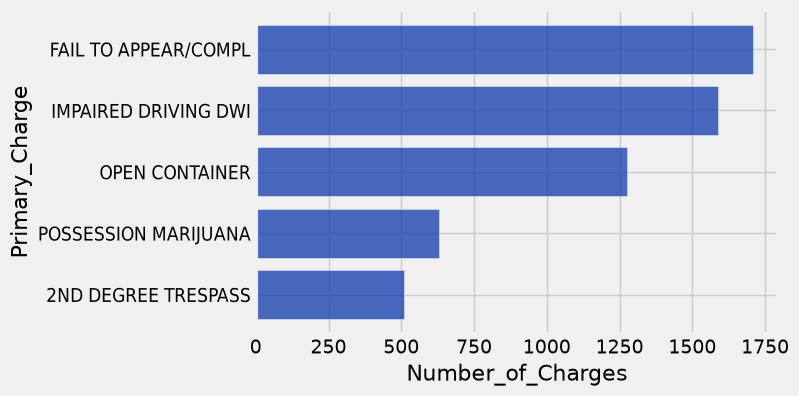

In [19]:
Primary_Charges.barh('Primary_Charge')

The `pivot` function is closely related to the `group` function: it groups together rows that share a combination of values. It differs from `group` because it organizes the resulting values in a grid. The first argument to `pivot` is the label of a column that contains the values that will be used to form new columns in the result. The second argument is the label of a column used for the rows. The result gives the count of all rows of the original table that share the combination of column and row values.

Like `group`, `pivot` can be used with additional arguments to find characteristics of each paired category. An optional third argument called values indicates a column of values that will replace the counts in each cell of the grid. All of these values will not be displayed, however; the fourth argument collect indicates how to collect them all into one aggregated value to be displayed in the cell.

Use the `pivot` function (and other table functions as needed) to answer question 4.3.

**Question 4.3.** For arrests in the 27514 `Zipcode`, is there a relationship between the average age for arrests depending on the type of arrest and if drugs or alcohol are present? 

To answer this question, make a table, `Arrest_types_drugs_or_alcohol`,  containing types of arrest as the rows, and the presence of drugs or alcohol as the columns, for the 27514 `Zipcode`. The values in the rows should correspond to the average age of those arrested for each combination of categories. Remove the rows with the `Drugs_or_Alcohol_Present` values of nan (blank) or *U* (unknown) as well as the column with the *Type_of_Arrest* value nan (blank).  

Hint: Run the cell below with the table `Arrest_NoBlanks` and use this table to construct the required table for this question. In the Arrests table there are many blank values for the age of those arrested. These blanks may lead to issues when attempting this question. Also dropped is the *Y* column for lattitude, as it may cause confusion for some possible outputs.

Note: Depending on how you go about answering this question, you may encounter a red box appearing below your code cell with a warning message. Don't worry too much about the message. Warnings are raised by Python when it encounters an unusual condition in your code, but the condition is not severe enough to warrant throwing an error.

In [20]:
Arrests_NoBlanks = Table.read_table('../../shared/Data/Police_Arrests_Made.csv'
                                   ).where("Age", are.above_or_equal_to(18)).drop('Y')

In [21]:
Arrest_27514 = (Arrests_NoBlanks
                .where('Zipcode', 27514)
                .where('Type_of_Arrest', are.not_equal_to('nan'))
                .where('Drugs_or_Alcohol_Present', are.not_equal_to('nan'))
                .where('Drugs_or_Alcohol_Present', are.not_equal_to('U')))
Arrest_types_drugs_or_alcohol = Arrest_27514.pivot('Drugs_or_Alcohol_Present',
                                                   'Type_of_Arrest',
                                                   'Age',
                                                   np.mean)
Arrest_types_drugs_or_alcohol

Type_of_Arrest,N,Y
ON VIEW,32.499,32.7972
SUMMONED/CITED,34.6571,36.472
TAKEN INTO CUSTODY (WARRANT/LP),33.713,39.7944


**Question 4.4.** What does the `Arrest_types_drugs_or_alcohol` table tell you about the relationship between the average age for arrests depending on the type of arrest and if drugs or alcohol are present in the 27514 `Zipcode`?

Yes, there appears to be a relationship. For every type of arrest in the 27514 Zipcode, arrests in which drugs or alcohol were present (Y) involve older individuals on average than arrests where they were not present (N). The gap is smallest for arrests made on view (about 32.5 vs. 32.8 years, roughly half a year) and largest for arrests where the person was taken into custody on a warrant/letter of protection (about 33.7 vs. 39.8 years, a difference of about 6 years), with summoned/cited arrests in between (about 34.7 vs. 36.5 years). So drug or alcohol involvement is associated with a higher average age of arrest, and the size of that association depends on the type of arrest.

Congratulations, you're done with homework 3!